# Pizza Sales Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset/pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## Data Cleaning

### Handling Null Values 

In [3]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

### Finding Duplicate Values and Removing Duplicate Values

In [4]:
find_duplicates = df.groupby('pizza_id')['pizza_id'].count().reset_index(name='pizza_count')
duplicate_values = find_duplicates['pizza_count'] > 1

In [5]:
find_duplicates[duplicate_values]

,pizza_id,pizza_count


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
fraud = pd.read_csv('Dataset/Fraud Detection Dataset.csv')

In [8]:
find_fraud_duplicates = fraud.groupby('Transaction_ID')['Transaction_ID'].count().reset_index(
    name='transaction_count'
)
duplicates = find_fraud_duplicates['transaction_count'] > 1
find_fraud_duplicates[duplicates]

,Transaction_ID,transaction_count
47,T1004,2
86,T10075,2
87,T10076,2
217,T10193,2
347,T1031,2
...,...,...
49930,T9936,2
49948,T9952,2
49954,T9958,2
49958,T9961,2


In [9]:
fraud = fraud.drop_duplicates(subset='Transaction_ID')

### Converting Data Types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df['order_time'] = pd.to_datetime(df['order_time'], format='mixed')

## Feature Engineering

### Extract Day, Month and Hour

In [12]:
# extract day name
df['Order_Day'] = df['order_date'].dt.day_name()
# extract month number
df['Order_Month_Num'] = df['order_date'].dt.month 
# extract month name
df['Order_Month_Name'] = df['order_date'].dt.month_name()
# extract hour
df['Order_Hour'] = df['order_time'].dt.hour

## KPIs (Key Performance Indicator)

In [13]:
'''
•	Total Revenue = Sum of total_price
•	Total Pizzas Sold = Sum of quantity
•	Total Orders = Count of unique order_id
•	Average Order Value (AOV) = Total Revenue ÷ Total Orders
•	Average Pizza per Order = Total Pizzas Sold ÷ Total Orders
'''

'\n•\tTotal Revenue = Sum of total_price\n•\tTotal Pizzas Sold = Sum of quantity\n•\tTotal Orders = Count of unique order_id\n•\tAverage Order Value (AOV) = Total Revenue ÷ Total Orders\n•\tAverage Pizza per Order = Total Pizzas Sold ÷ Total Orders\n'

In [14]:
total_revenue = df['total_price'].sum()
total_pizza_sold = df['quantity'].sum()
# count -> value count
# nunique() -> number of unique value count
total_orders = df['order_id'].nunique()
average_order_value = total_revenue / total_orders
average_pizza_per_order = total_pizza_sold / total_orders

In [15]:
# print(f'Total Revenue: Rs.{round(total_revenue, 2)}')
print(f'Total Revenue: Rs.{total_revenue:,.2f}')
print(f'Total Pizza Sold: {total_pizza_sold} pcs.')
print(f'Total Orders: {total_orders:,.0f}')
print(f'Average Order Value: Rs.{average_order_value:,.2f}')
print(f'Average Pizza Per Order: {average_pizza_per_order:.2f} pcs.')

Total Revenue: Rs.817,860.05
Total Pizza Sold: 49574 pcs.
Total Orders: 21,350
Average Order Value: Rs.38.31
Average Pizza Per Order: 2.32 pcs.


## Analysis

### Daily Trend - Sales by Day of the Week.

In [16]:
weekdays = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['Order_Day'] = pd.Categorical(df['Order_Day'], categories=weekdays)

In [17]:
day_sales = df.groupby('Order_Day', observed=False)['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)
day_sales['Total_Price'] = day_sales['Total_Price'].map("Rs.{:,.2f}".format)
day_sales

,Order_Day,Total_Price
0,Sunday,"Rs.102,116.45"
1,Monday,"Rs.110,471.60"
2,Tuesday,"Rs.115,594.45"
3,Wednesday,"Rs.116,731.20"
4,Thursday,"Rs.121,650.30"
5,Friday,"Rs.129,690.90"
6,Saturday,"Rs.121,605.15"


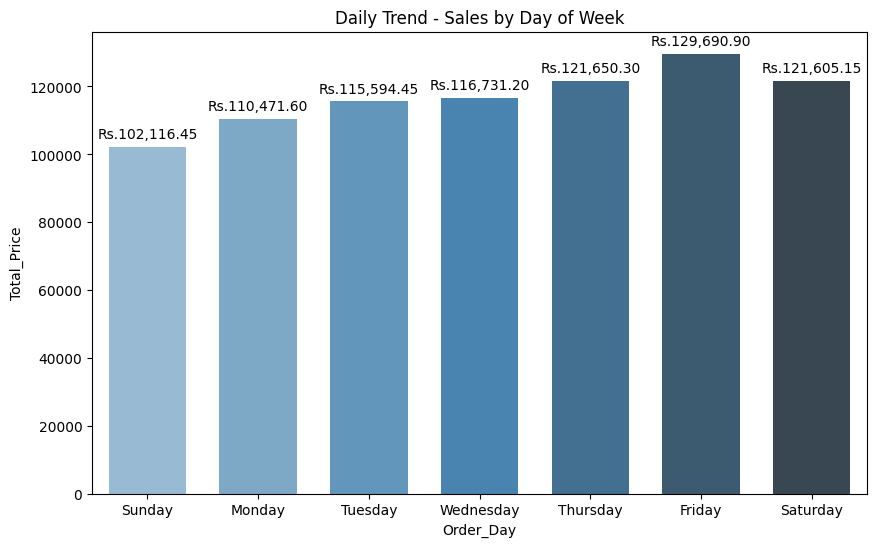

In [18]:
v_day_sales = df.groupby('Order_Day', observed=False)['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=v_day_sales, x=v_day_sales['Order_Day'], y=v_day_sales['Total_Price'],
           palette='Blues_d', width=0.7)
plt.title('Daily Trend - Sales by Day of Week')
for container in ax.containers:
    plt.bar_label(container, fmt='Rs.{:,.2f}', padding=4)
plt.show()

### Hourly Trend - Sales by Hour of the Day

In [19]:
hour_sales = df.groupby('Order_Hour')['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)
hour_sales['Total_Price'] = hour_sales['Total_Price'].map("Rs.{:,.2f}".format)
hour_sales

,Order_Hour,Total_Price
0,9,Rs.83.00
1,10,Rs.303.65
2,11,"Rs.44,935.80"
3,12,"Rs.111,877.90"
4,13,"Rs.106,065.70"
5,14,"Rs.59,201.40"
6,15,"Rs.52,992.30"
7,16,"Rs.70,055.40"
8,17,"Rs.86,237.45"
9,18,"Rs.89,296.85"


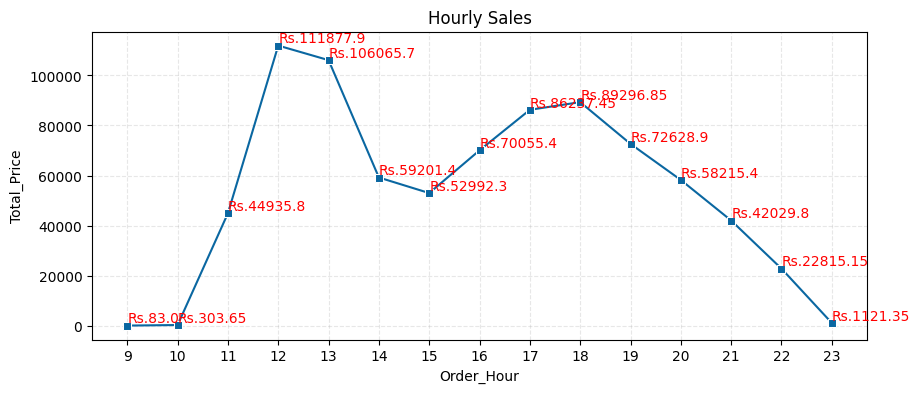

In [20]:
v_hour_sales = df.groupby('Order_Hour')['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)

plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=v_hour_sales, x='Order_Hour', y='Total_Price', color='#0A67A1', marker='s')
plt.grid(linestyle='dashed', alpha=0.3)
plt.title('Hourly Sales')
plt.xticks(v_hour_sales['Order_Hour'])

for idx, val in enumerate(v_hour_sales['Total_Price']):
    format_val = f'Rs.{val}'
    plt.text(v_hour_sales['Order_Hour'][idx], val, format_val, ha='left', va='bottom', color='red')

### Monthly Trend - Depicting Monthly Revenue and Orders

In [21]:
monthly_sales = df.groupby(['Order_Month_Num', 'Order_Month_Name'])['total_price'].sum().reset_index(
    ).rename(
    columns = {'Order_Month_Name': 'Order_Month', 'total_price': 'Total_Price'}
)
monthly_sales['Total_Price'] = monthly_sales['Total_Price'].map("Rs.{:,.2f}".format)
monthly_sales[['Order_Month', 'Total_Price']]

,Order_Month,Total_Price
0,January,"Rs.71,620.15"
1,February,"Rs.64,419.45"
2,March,"Rs.71,301.40"
3,April,"Rs.70,312.00"
4,May,"Rs.67,648.80"
5,June,"Rs.68,161.45"
6,July,"Rs.70,880.65"
7,August,"Rs.69,497.30"
8,September,"Rs.63,803.70"
9,October,"Rs.68,152.20"


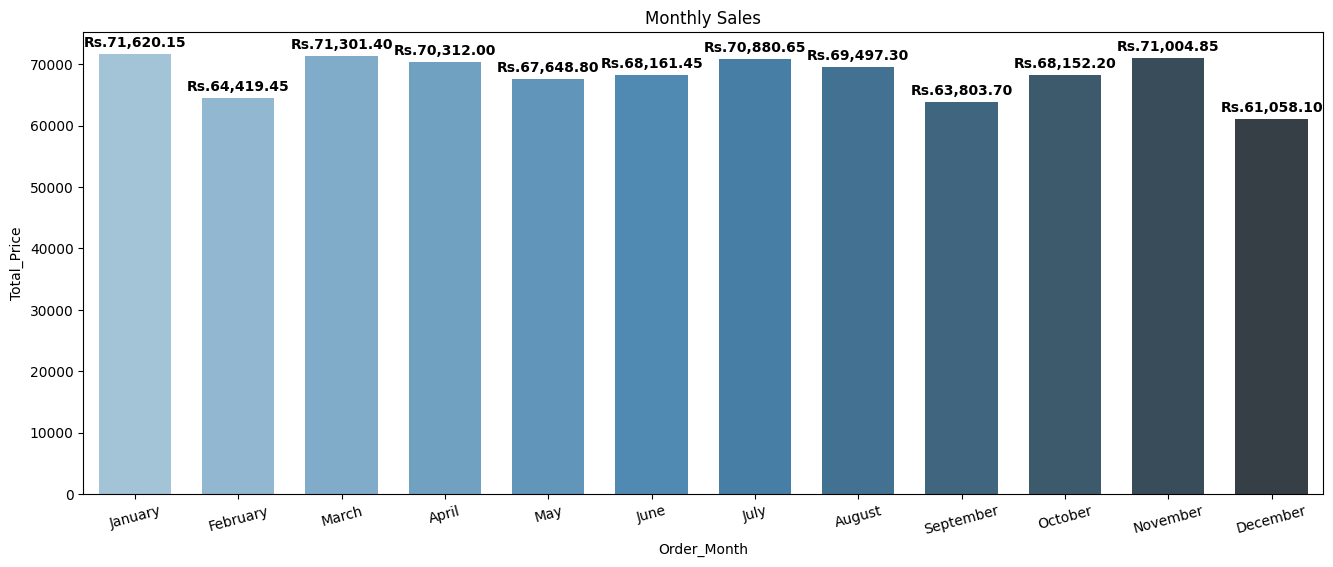

In [22]:
v_monthly_sales = df.groupby(['Order_Month_Num', 'Order_Month_Name'])['total_price'].sum().reset_index(
    ).rename(
    columns = {'Order_Month_Name': 'Order_Month', 'total_price': 'Total_Price'}
)

plt.figure(figsize=(16, 6))
ax = sns.barplot(data=v_monthly_sales, x='Order_Month', y='Total_Price', width=0.7, palette='Blues_d')
plt.xticks(rotation=15)
plt.title('Monthly Sales')

for container in ax.containers:
    plt.bar_label(container, fmt='Rs.{:,.2f}', padding=3, fontweight='bold')
plt.show()

### % of Sales by Category

In [23]:
cat_sales_pct = df.groupby('pizza_category')['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)
cat_sales_pct['Total_Sales%'] = (cat_sales_pct['Total_Price']/total_revenue)*100
cat_sales_pct['Total_Sales%'] = cat_sales_pct['Total_Sales%'].map("Rs.{:,.2f}%".format)
cat_sales_pct['Total_Price'] = cat_sales_pct['Total_Price'].map("Rs.{:,.2f}".format)
cat_sales_pct

,pizza_category,Total_Price,Total_Sales%
0,Chicken,"Rs.195,919.50",Rs.23.96%
1,Classic,"Rs.220,053.10",Rs.26.91%
2,Supreme,"Rs.208,197.00",Rs.25.46%
3,Veggie,"Rs.193,690.45",Rs.23.68%


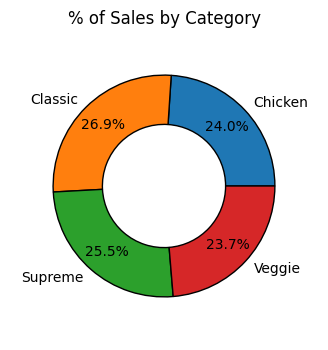

In [24]:
v_cat_sales_pct = df.groupby('pizza_category')['total_price'].sum().reset_index().rename(
    columns = {'total_price': 'Total_Price'}
)
v_cat_sales_pct['Total_Sales%'] = round((v_cat_sales_pct['Total_Price']/total_revenue)*100, 2)

plt.figure(figsize=(6, 4))
plt.pie(
    v_cat_sales_pct['Total_Sales%'],
    labels=v_cat_sales_pct['pizza_category'],
    autopct='%1.1f%%',
    radius=0.9,
    pctdistance=0.78,
    wedgeprops={'width':0.4, 'edgecolor':'black'}
)
plt.title('% of Sales by Category')
plt.show()

### % Sales by Pizza Size & Category

In [25]:
pizza_size_cat_pct = df.groupby(['pizza_size', 'pizza_category'])['total_price'].sum().reset_index(
).rename(columns = {'total_price': 'Total_Price'})
pizza_size_cat_pct['Sales%'] = (pizza_size_cat_pct['Total_Price']/total_revenue)*100
pizza_size_cat_pct['Sales%'] = pizza_size_cat_pct['Sales%'].map('{:,.2f}%'.format)
pizza_size_cat_pct

,pizza_size,pizza_category,Total_Price,Sales%
0,L,Chicken,102339.00,12.51%
1,L,Classic,74518.50,9.11%
2,L,Supreme,94258.50,11.53%
3,L,Veggie,104202.70,12.74%
4,M,Chicken,65224.50,7.98%
5,M,Classic,60581.75,7.41%
6,M,Supreme,66475.00,8.13%
7,M,Veggie,57101.00,6.98%
8,S,Chicken,28356.00,3.47%
9,S,Classic,69870.25,8.54%


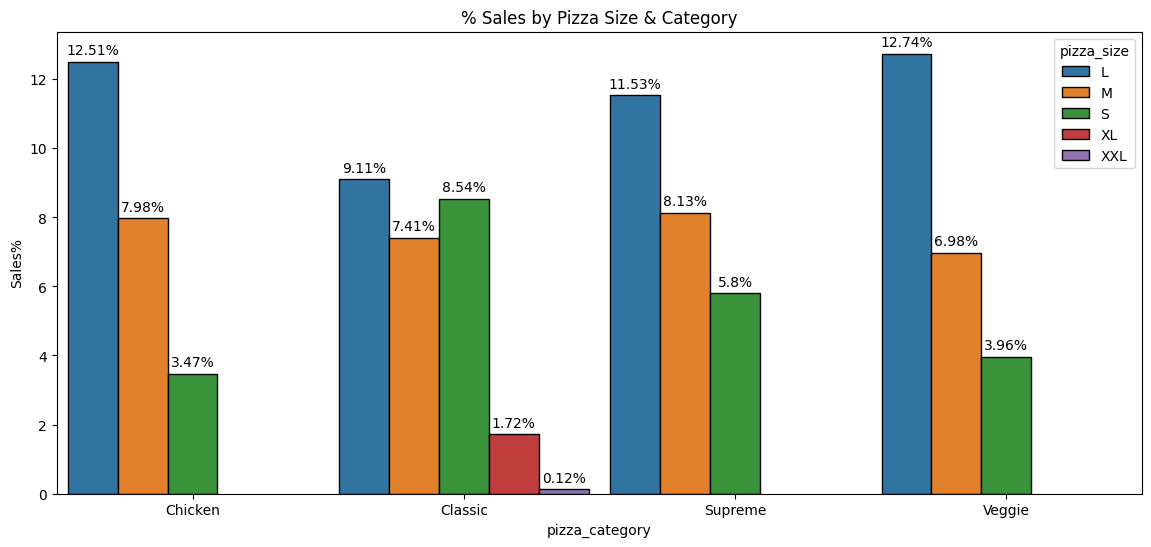

In [26]:
pizza_size_cat_pct = df.groupby(['pizza_size', 'pizza_category'])['total_price'].sum().reset_index(
).rename(columns = {'total_price': 'Total_Price'})
pizza_size_cat_pct['Sales%'] = round((pizza_size_cat_pct['Total_Price']/total_revenue)*100, 2)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=pizza_size_cat_pct, x='pizza_category', y='Sales%', hue='pizza_size',
                edgecolor='black', width=0.92)
plt.title('% Sales by Pizza Size & Category')
for container in ax.containers:
    plt.bar_label(container, fmt='{}%', padding=3)
plt.show()

### Total Pizzas Sold by Pizza Category

In [27]:
total_pizza_cat = df.groupby('pizza_category')['quantity'].sum().reset_index().rename(
    columns = {'quantity':'Total_Pizza_Sold'}
)
total_pizza_cat

,pizza_category,Total_Pizza_Sold
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


### Top 5 Best-Selling Pizzas

In [28]:
top_5_pizza = df.groupby('pizza_name').agg(
    Total_Sales = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique'),
    Total_Quantity = ('quantity', 'sum')
).reset_index().sort_values(ascending=False, by='Total_Sales', ignore_index=True).head()
top_5_pizza['Total_Sales'] = top_5_pizza['Total_Sales'].map("Rs.{:,.2f}".format)
top_5_pizza['Total_Quantity'] = top_5_pizza['Total_Quantity'].map("{:,.0f} pcs.".format)
top_5_pizza

,pizza_name,Total_Sales,Total_Orders,Total_Quantity
0,The Thai Chicken Pizza,"Rs.43,434.25",2225,"2,371 pcs."
1,The Barbecue Chicken Pizza,"Rs.42,768.00",2273,"2,432 pcs."
2,The California Chicken Pizza,"Rs.41,409.50",2197,"2,370 pcs."
3,The Classic Deluxe Pizza,"Rs.38,180.50",2329,"2,453 pcs."
4,The Spicy Italian Pizza,"Rs.34,831.25",1822,"1,924 pcs."


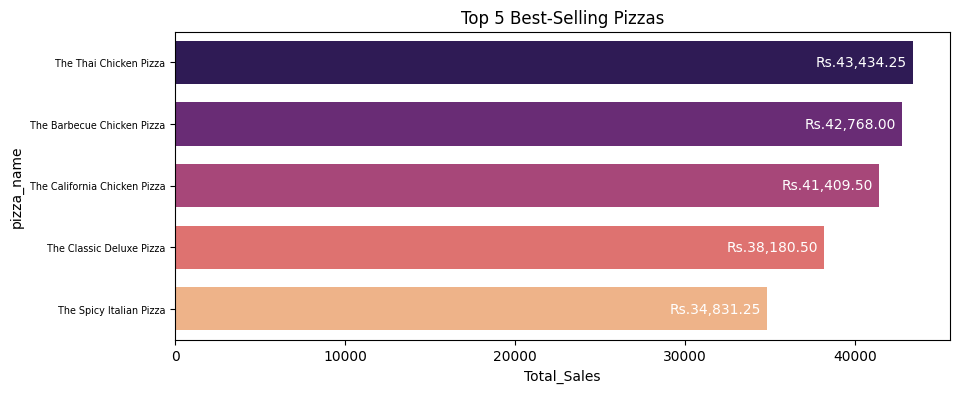

In [29]:
top_5_pizza = df.groupby('pizza_name').agg(
    Total_Sales = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique'),
    Total_Quantity = ('quantity', 'sum')
).reset_index().sort_values(ascending=False, by='Total_Sales', ignore_index=True).head()

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=top_5_pizza, x='Total_Sales', y='pizza_name', width=0.7, palette='magma')
plt.yticks(fontsize='x-small')
plt.title('Top 5 Best-Selling Pizzas')

for container in ax.containers:
    plt.bar_label(container, fmt='Rs.{:,.2f}', label_type='edge', padding=-70, color='#fff')
plt.show()

### Bottom 5 Least-Selling Pizzas

In [30]:
bottom_5_least_selling_pizza = df.groupby('pizza_name').agg(
    Total_Sales = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique'),
    Total_Quantity = ('quantity', 'sum')
).reset_index().sort_values(ascending=True, by='Total_Sales', ignore_index=True).head()
bottom_5_least_selling_pizza['Total_Sales'] = bottom_5_least_selling_pizza['Total_Sales'].map("Rs.{:,.2f}".format)
bottom_5_least_selling_pizza['Total_Quantity'] = bottom_5_least_selling_pizza['Total_Quantity'].map("{:,.0f} pcs.".format)
bottom_5_least_selling_pizza

,pizza_name,Total_Sales,Total_Orders,Total_Quantity
0,The Brie Carre Pizza,"Rs.11,588.50",480,490 pcs.
1,The Green Garden Pizza,"Rs.13,955.75",976,997 pcs.
2,The Spinach Supreme Pizza,"Rs.15,277.75",918,950 pcs.
3,The Mediterranean Pizza,"Rs.15,360.50",912,934 pcs.
4,The Spinach Pesto Pizza,"Rs.15,596.00",945,970 pcs.


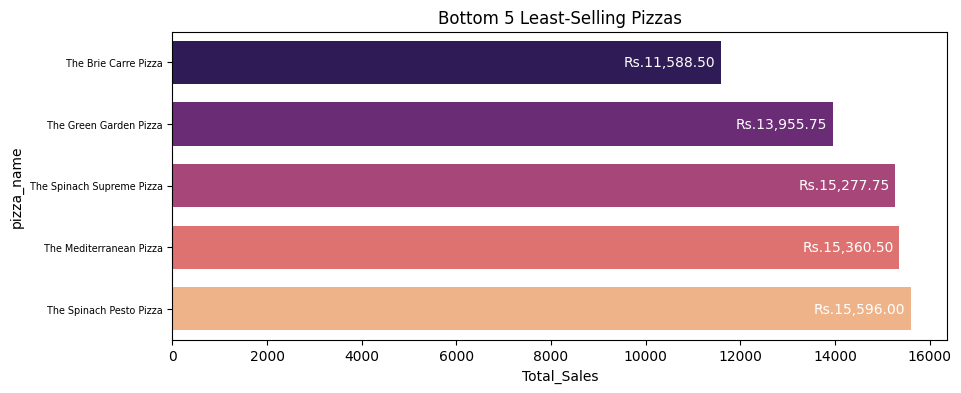

In [31]:
bottom_5_least_selling_pizza = df.groupby('pizza_name').agg(
    Total_Sales = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique'),
    Total_Quantity = ('quantity', 'sum')
).reset_index().sort_values(ascending=True, by='Total_Sales', ignore_index=True).head()

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=bottom_5_least_selling_pizza, x='Total_Sales', y='pizza_name', width=0.7, palette='magma')
plt.yticks(fontsize='x-small')
plt.title('Bottom 5 Least-Selling Pizzas')

for container in ax.containers:
    plt.bar_label(container, fmt='Rs.{:,.2f}', label_type='edge', padding=-70, color='#fff')
plt.show()